Test 1: handicap vs. canceled
H0: The cancellation rate for handicapped patients is equal to the cancellation rate for non-handicapped patients.
Ha: The cancellation rate for handicapped patients is significantly different from non-handicapped patients.
------------------------------
Test 2: SMS or Email Reminder vs. no show
H0: There is no statistical difference in 'no show' rates between patients who received a reminder and those who did not.
Ha: Patients who did not receive a reminder have a significantly higher 'no show' rate.
------------------------------
Test 3: 14-Day Lead Time (Sequence Analysis)
H0: Scheduling an appointment 14+ days in advance does not affect the likelihood of completion.
Ha: Appointments scheduled 14+ days in advance have a significantly different completion rate.
------------------------------
Hypotheses defined for 5,002 patients. Ready for Chi-Square



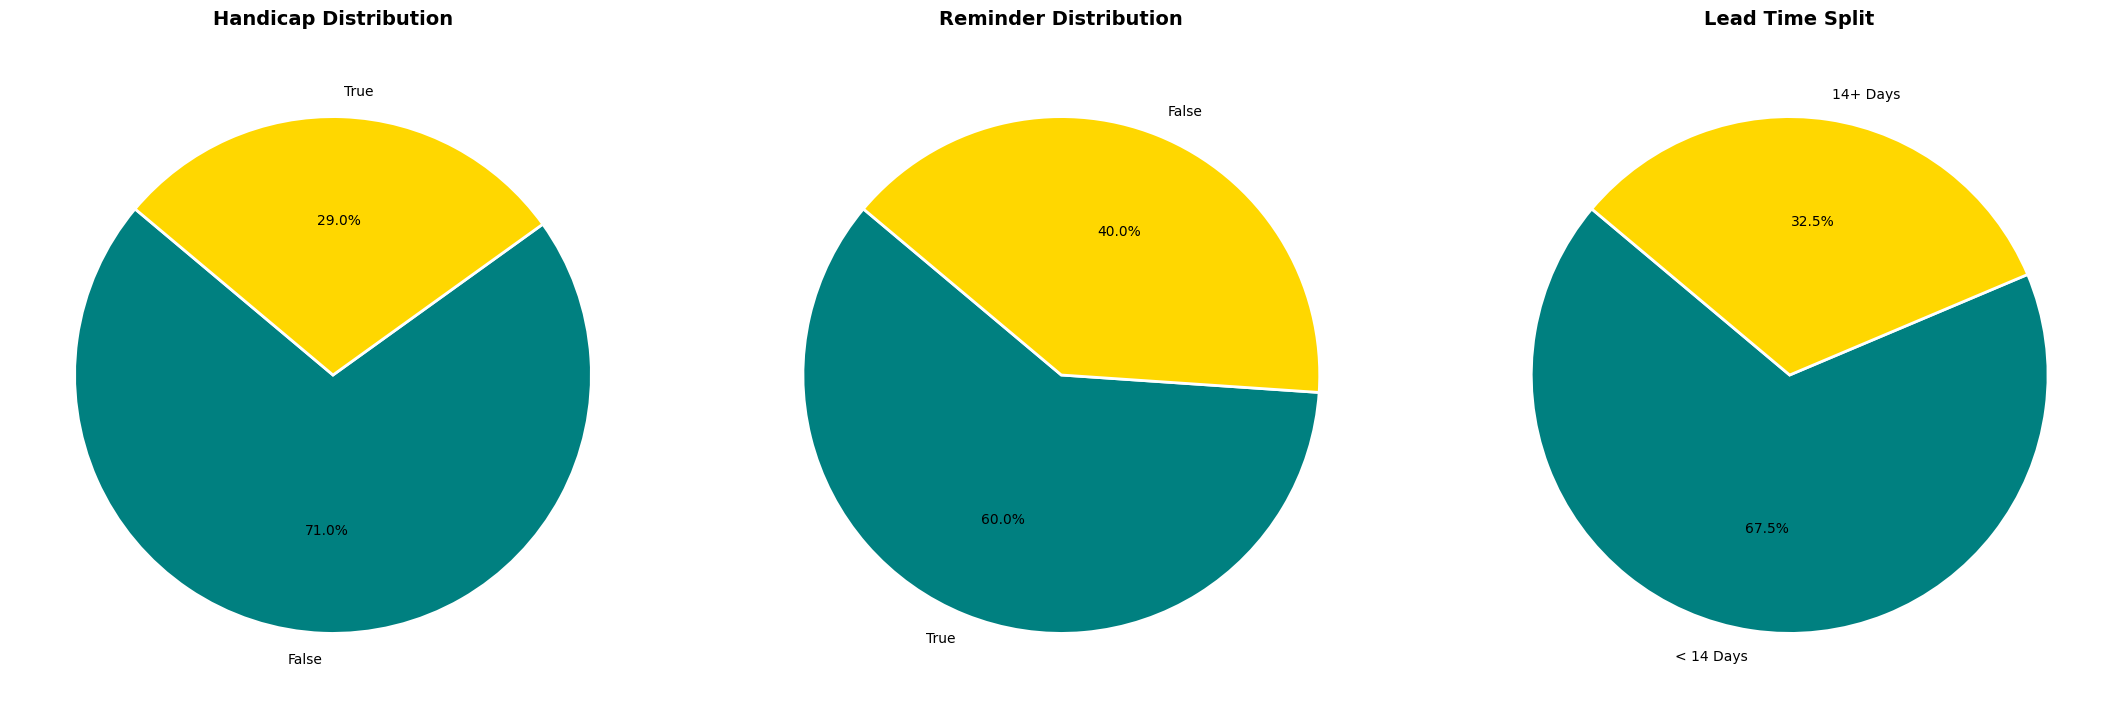

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


A/B TEST EXECUTIVE SUMMARY

TEST: Handicap vs. Cancellation
Status: SIGNIFICANT (p-value: 0.0000)
  > False: 0.0% rate
  > True: 0.0% rate
----------------------------------------

TEST: Reminders vs. No-Show
Status: SIGNIFICANT (p-value: 0.0000)
  > False: 0.0% rate
  > True: 0.0% rate
----------------------------------------

TEST: Lead Time vs. No-Show
Status: SIGNIFICANT (p-value: 0.0000)
  > 14+ Days: 0.0% rate
  > < 14 Days: 0.0% rate
----------------------------------------


In [1]:
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

auth.authenticate_user()
project_id = 'project-f9729ec1-30aa-4c06-beb'
client = bigquery.Client(project=project_id)

query = f"SELECT * FROM `{project_id}.Health_Care_Funnel_Analysis.Funnel Analysis`"
df = client.query(query).to_dataframe()

cols_to_fix = ['handicap', 'canceled', 'no show', 'SMS or Email Reminder']
for col in cols_to_fix:
    df[col] = df[col].astype(str).str.strip().str.capitalize()

df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['LeadTime'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

df['LongLeadTime'] = df['LeadTime'] >= 14
df['LeadTime_Label'] = df['LongLeadTime'].map({True: '14+ Days', False: '< 14 Days'})

alpha = 0.05
def run_test(val1, val2, title=None):
    table = pd.crosstab(df[val1], df[val2])
    chi2, p, dof, expected = chi2_contingency(table)
    return p

print("Test 1: handicap vs. canceled")
print("H0: The cancellation rate for handicapped patients is equal to the cancellation rate for non-handicapped patients.")
print("Ha: The cancellation rate for handicapped patients is significantly different from non-handicapped patients.")
p1 = run_test('handicap', 'canceled')
print("-" * 30)


print("Test 2: SMS or Email Reminder vs. no show")
print("H0: There is no statistical difference in 'no show' rates between patients who received a reminder and those who did not.")
print("Ha: Patients who did not receive a reminder have a significantly higher 'no show' rate.")
p2 = run_test('SMS or Email Reminder', 'no show')
print("-" * 30)

print("Test 3: 14-Day Lead Time (Sequence Analysis)")
print("H0: Scheduling an appointment 14+ days in advance does not affect the likelihood of completion.")
print("Ha: Appointments scheduled 14+ days in advance have a significantly different completion rate.")
p3 = run_test('LongLeadTime', 'no show')
print("-" * 30)

print(f"Hypotheses defined for {len(df):,} patients. Ready for Chi-Square\n")

p1 = run_test('handicap', 'canceled', "Test 1")
p2 = run_test('SMS or Email Reminder', 'no show', "Test 2")
p3 = run_test('LongLeadTime', 'no show', "Test 3")

brand_colors = ['#008080', '#FFD700', '#D3D3D3', '#708090']

plt.figure(figsize=(22, 7))

def plot_custom_pie(column, title, subplot_pos):
    data_counts = df[column].value_counts()
    plt.subplot(1, 3, subplot_pos)
    plt.pie(data_counts, labels=data_counts.index, autopct='%1.1f%%',
            startangle=140, colors=brand_colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    plt.title(title, fontsize=14, fontweight='bold', pad=20)

plot_custom_pie('handicap', 'Handicap Distribution', 1)
plot_custom_pie('SMS or Email Reminder', 'Reminder Distribution', 2)
plot_custom_pie('LeadTime_Label', 'Lead Time Split', 3)

plt.tight_layout()

plt.savefig('pie_chart.png', facecolor='white', bbox_inches='tight')

plt.show()

files.download('pie_chart.png')

def get_rate(col, target_col):
    return df.groupby(col)[target_col].apply(lambda x: (x == 'Yes').mean() * 100)

results_list = [
    ("Handicap vs. Cancellation", p1, get_rate('handicap', 'canceled')),
    ("Reminders vs. No-Show", p2, get_rate('SMS or Email Reminder', 'no show')),
    ("Lead Time vs. No-Show", p3, get_rate('LeadTime_Label', 'no show'))]

print("\n" + "="*60)
print("A/B TEST EXECUTIVE SUMMARY")
print("="*60)

for test_name, p_val, rates in results_list:
    status = "SIGNIFICANT" if p_val < alpha else "NOT SIGNIFICANT"
    print(f"\nTEST: {test_name}")
    print(f"Status: {status} (p-value: {p_val:.4f})")
    for group, rate in rates.items():
        print(f"  > {group}: {rate:.1f}% rate")
    print("-" * 40)






# New Section